<a href="https://colab.research.google.com/github/agief-G1A024037/Kelompok-07-09-015-037-041-/blob/main/Bagian1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Survival Titanic & Klasifikasi Citra Sederhana

## Bagian 1: Decision Tree (Titanic)
Analisis dilakukan berdasarkan model decision tree pada slide.

## Bagian 2: Klasifikasi Citra
Menggunakan dataset Digits untuk membandingkan Decision Tree dan KNN.

In [ ]:
def predict_titanic(sex, age, sibsp):
    # sex: 0 = male, 1 = female

    if sex == 1:
        return "Selamat", 0.73
    else:
        if age > 9.5:
            return "Meninggal", 0.17
        else:
            if sibsp >= 3:
                return "Meninggal", 0.02
            else:
                return "Selamat", 0.89

# Kasus soal
hasil, prob = predict_titanic(0, 8, 4)

print("=== HASIL ANALISIS TITANIC ===")
print("Prediksi:", hasil)
print("Probabilitas selamat:", prob)
print("Probabilitas meninggal:", 1 - prob)

=== HASIL ANALISIS TITANIC ===
Prediksi: Meninggal
Probabilitas selamat: 0.02
Probabilitas meninggal: 0.98


## Analisis Decision Tree

Berdasarkan decision tree pada slide:

- Gender: male
- Age: 8 (≤ 9.5)
- SibSp: 4 (≥ 3)

Maka jalur keputusan:
Male → Age ≤ 9.5 → SibSp ≥ 3 → died (0.02; 2%)

Kesimpulan:
Penumpang diprediksi meninggal dengan probabilitas selamat sebesar 2%, sehingga kemungkinan meninggal sekitar 98%.

### Parametric Learner

Model ini disebut parametric learner karena memiliki struktur tetap berupa node dan aturan split yang tidak berubah setelah training. Parameter model terbatas dan tidak bertambah saat menerima data baru.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Jumlah data: 1797
Jumlah fitur: 64


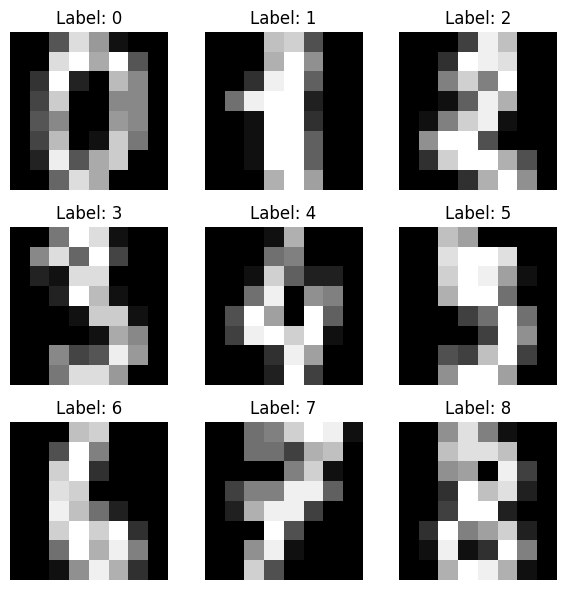

In [ ]:
digits = load_digits()

X = digits.data
y = digits.target

print("Jumlah data:", len(X))
print("Jumlah fitur:", X.shape[1])

# Visualisasi
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

In [ ]:
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("=== HASIL AKURASI ===")
print("Decision Tree :", acc_dt)
print("KNN           :", acc_knn)

=== HASIL AKURASI ===
Decision Tree : 0.6638888888888889
KNN           : 0.9861111111111112


In [ ]:
print("\n=== CONFUSION MATRIX - Decision Tree ===")
print(confusion_matrix(y_test, y_pred_dt))

print("\n=== CONFUSION MATRIX - KNN ===")
print(confusion_matrix(y_test, y_pred_knn))

print("\n=== REPORT - Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

print("\n=== REPORT - KNN ===")
print(classification_report(y_test, y_pred_knn))


=== CONFUSION MATRIX - Decision Tree ===
[[29  0  1  0  1  1  0  0  1  0]
 [ 0  7  1  2  3  0  0  0 15  0]
 [ 0  0  7  1  0  1  1  1 22  0]
 [ 0  2  1 28  0  0  0  0  3  0]
 [ 0  2  1  0 36  0  0  2  3  2]
 [ 0  1  0  1  1 39  1  0  0  4]
 [ 0  1  0  0  1  0 33  0  0  0]
 [ 0  2  1  2  0  0  0 24  5  0]
 [ 0  0  0  8  0  0  0  0 22  0]
 [ 0  1  0 25  0  0  0  0  0 14]]

=== CONFUSION MATRIX - KNN ===
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  0  1  1  0  0  0 38]]

=== REPORT - Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        33
           1       0.44      0.25      0.32        28
           2       0.58      0.21      0.31        33
           3   

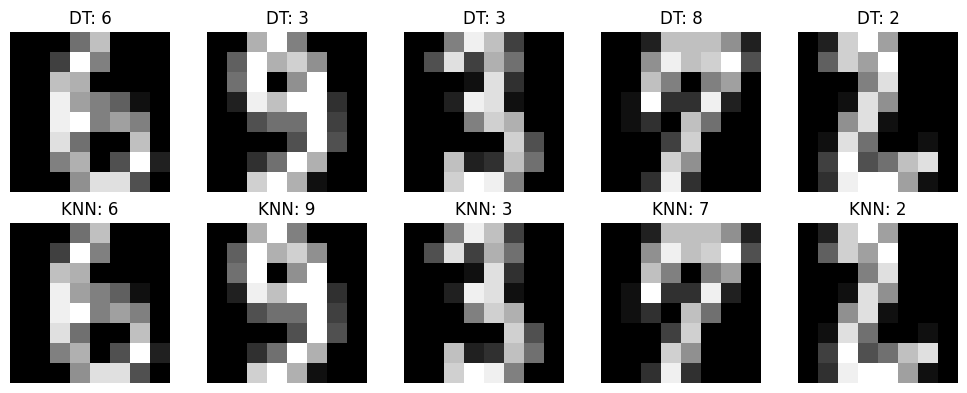

In [ ]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    plt.title(f"DT: {y_pred_dt[i]}")
    plt.axis('off')

for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    plt.title(f"KNN: {y_pred_knn[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Analisis Perbandingan Model

KNN memiliki akurasi yang lebih tinggi dibandingkan Decision Tree karena bersifat non-parametric, yaitu menyimpan seluruh data training sehingga lebih fleksibel terhadap pola yang kompleks.

Sebaliknya, Decision Tree bersifat lebih sederhana dan cepat karena menggunakan aturan tetap (parametric sederhana), namun dapat kehilangan detail pola data.